In [44]:
from pandas import DataFrame,read_csv
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score,f1_score,recall_score,precision_score,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay)

import joblib

In [2]:
df = read_csv("data/Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.isna().sum().sum()

np.int64(866)

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_new = df.drop(["Name","PassengerId","Ticket","Cabin"],axis=1)

Survived
0    549
1    342
Name: count, dtype: int64
-------------------------------------------------------------------------------------
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
-------------------------------------------------------------------------------------


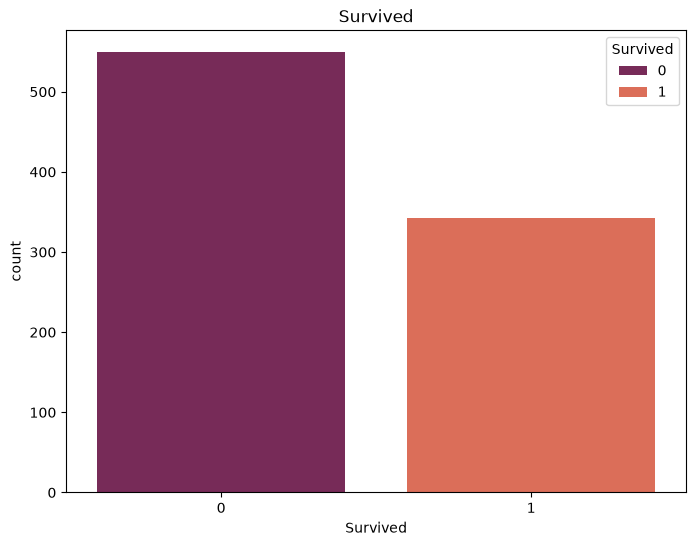

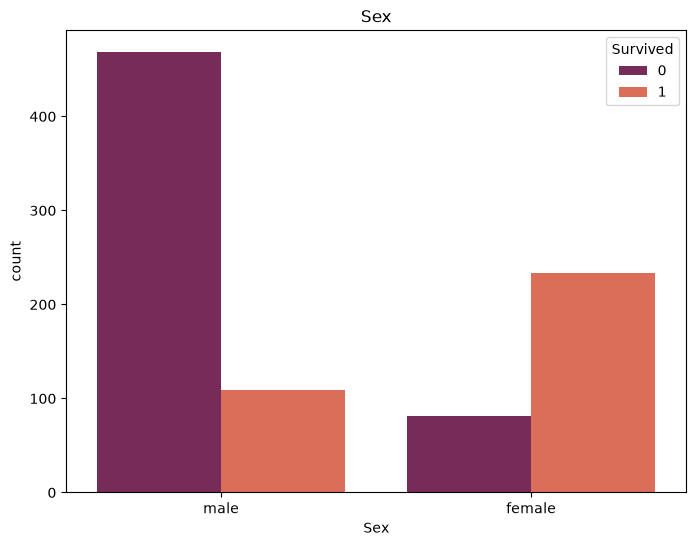

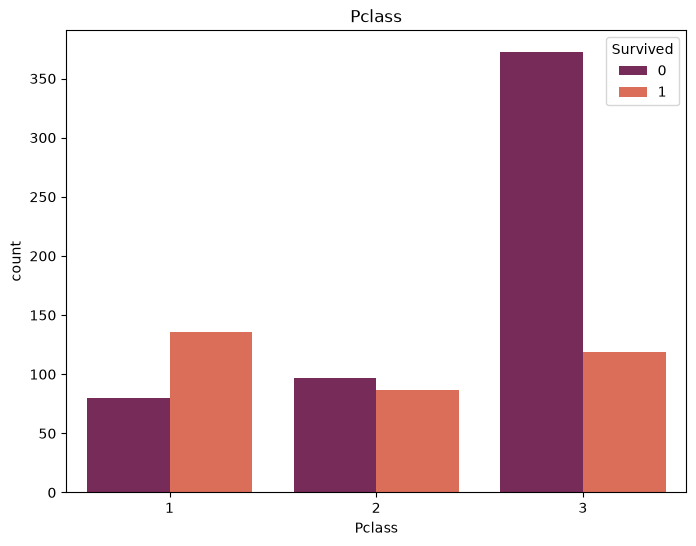

In [13]:
print(df_new["Survived"].value_counts())
print("-"*85)

print(df_new["Survived"].value_counts(normalize=True)*100)
print("-"*85)

col_count = {
    "Survived":"Survived",
    "Sex":"Sex",
    "Pclass":"Pclass"
}

for col,ti in col_count.items():
    plt.figure(figsize=(8,6))
    sns.countplot(df_new,x=col,palette="rocket",hue="Survived")
    plt.title(ti)
    plt.savefig(f"images/Countplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()


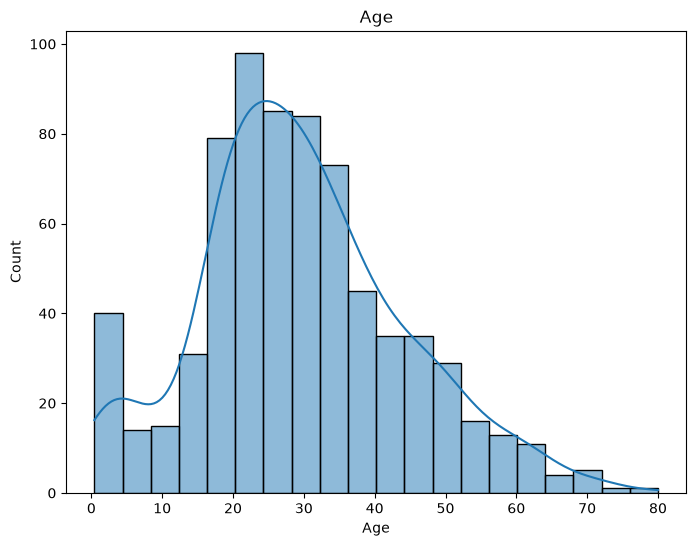

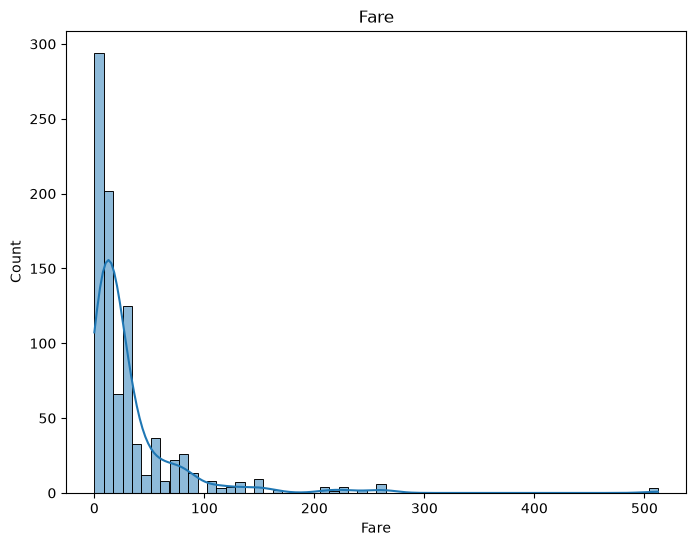

In [14]:
col_hist = {
    "Age":"Age",
    "Fare":"Fare"
}
for col,ti in col_hist.items():
    plt.figure(figsize=(8,6))
    sns.histplot(df_new,x=col,kde=True)
    plt.title(ti)
    plt.savefig(f"images/Histplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()

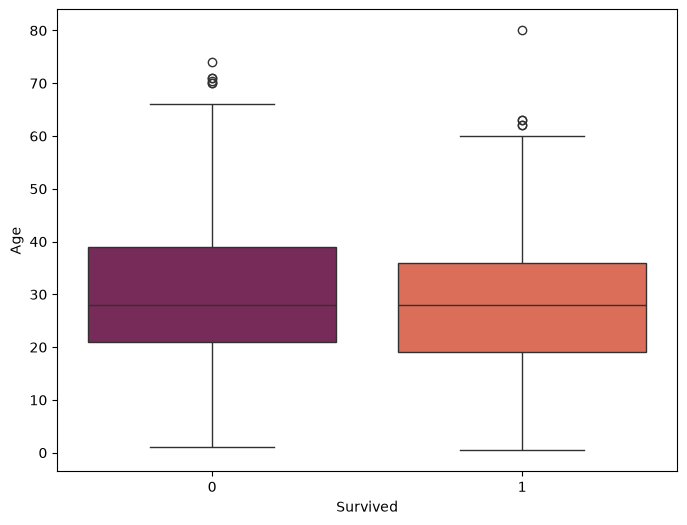

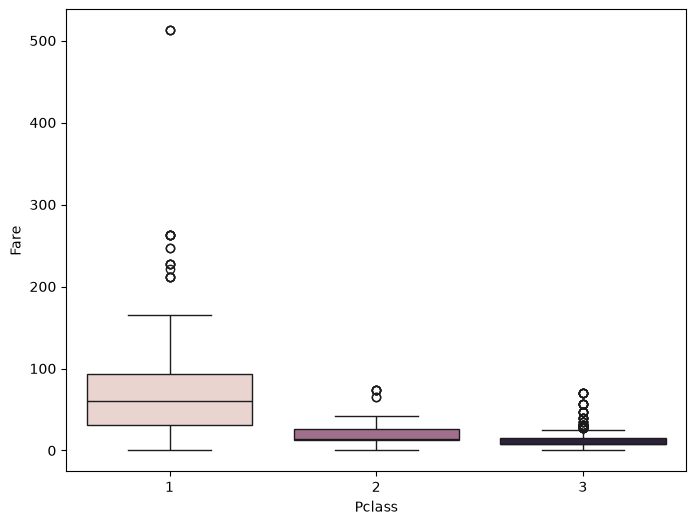

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(df_new,x="Survived",y="Age",palette="rocket",hue="Survived",legend=False)
plt.savefig(f"images/Boxplots/Survived-vs-Age.png",
        dpi=300,
        bbox_inches="tight")
plt.show()


plt.figure(figsize=(8,6))
sns.boxplot(df_new,x="Pclass",y="Fare",hue="Pclass",legend=False)
plt.savefig(f"images/Boxplots/Pclass-vs-Fare.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

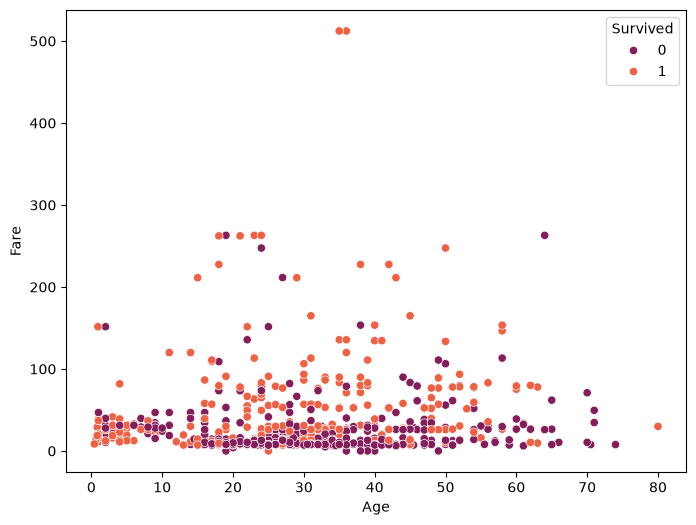

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(df_new,x="Age",y="Fare",hue="Survived",palette="rocket")
plt.savefig(f"images/Scatterplots/Age-vs-Fare.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

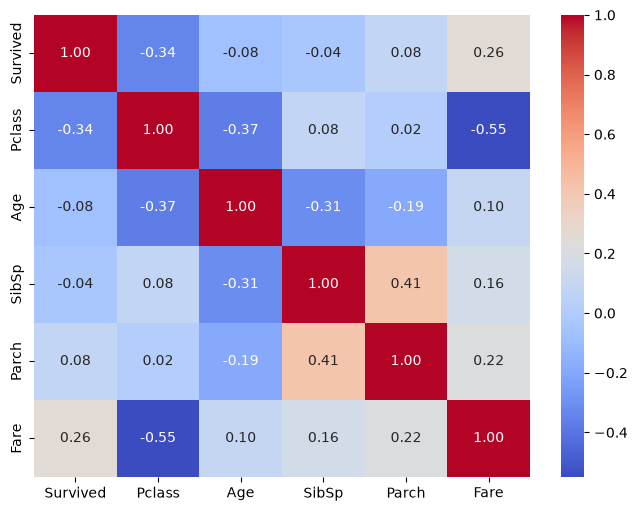

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df_new.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.savefig(f"images/Heatmap/heatmap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [18]:
X = df_new.drop("Survived",axis=1)
y = df_new["Survived"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [19]:
numeric_col = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
cat_col = ["Sex", "Embarked"]

In [20]:
preprocessor = ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric_col),
    ("cat",Pipeline([
        ("impute",SimpleImputer(strategy="most_frequent")),
        ("encod",OneHotEncoder(handle_unknown="ignore"))
    ]),cat_col)
])

Random Forest

In [21]:
pipeline_RF = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

param_RF = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [22]:
grid_RF = RandomizedSearchCV(pipeline_RF,param_RF,n_iter=50,cv=5,n_jobs=-1,verbose=1,scoring="accuracy")

In [23]:
grid_RF.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_es

In [24]:
print("-"*40,"RandomForestClassifier","-"*40)
print("Best Params : ",grid_RF.best_params_)
print("Best Score : ",grid_RF.best_score_)

---------------------------------------- RandomForestClassifier ----------------------------------------
Best Params :  {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best Score :  0.8338570306362921


XGBoost

In [25]:
pipeline_XG = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(random_state=42,eval_metric="logloss"))
])

param_XG = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

In [26]:
grid_XG = RandomizedSearchCV(pipeline_XG,param_XG,n_iter=50,cv=5,n_jobs=-1,verbose=1,scoring="accuracy")

In [27]:
grid_XG.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``bes

In [28]:
print("-"*40,"XGBClassifier","-"*40)
print("Best Param : ",grid_XG.best_params_)
print("Best Score : ",grid_XG.best_score_)

---------------------------------------- XGBClassifier ----------------------------------------
Best Param :  {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
Best Score :  0.8353383458646617


LightGBM

In [29]:
pipeline_LGBM = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LGBMClassifier(random_state=42,verbosity=-1,n_jobs=1))
])

param_lgbm = {
    "model__n_estimators": [100, 200],
    "model__num_leaves": [15, 31],
    "model__learning_rate": [0.05, 0.1]
}

In [30]:
grid_lgbm = GridSearchCV(pipeline_LGBM,param_lgbm,cv=5,scoring="accuracy",n_jobs=1,verbose=1)

In [31]:
grid_lgbm.fit(x_train,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [100, 200], 'model__num_leaves': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_select

In [32]:
print("-"*40,"LGBMClassifier","-"*40)
print("Best Params : ",grid_lgbm.best_params_)
print("Best Score : ",grid_lgbm.best_score_)

---------------------------------------- LGBMClassifier ----------------------------------------
Best Params :  {'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 15}
Best Score :  0.8338570306362921


Catboost

In [33]:
X_cat = df_new.drop(columns="Survived")
y_cat = df_new["Survived"]

X_cat["Age"] = X_cat["Age"].fillna(X_cat["Age"].median())
X_cat["Embarked"] = X_cat["Embarked"].fillna(X_cat["Embarked"].mode()[0])


x_train_cat, x_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat,y_cat,test_size=0.25,random_state=42,stratify=y_cat)

In [34]:
preprocessor_catboost = ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric_col)], remainder="passthrough")

In [35]:
cat_features = ["Sex", "Embarked"]

cat_model = CatBoostClassifier(random_seed=42,verbose=0,thread_count=1)

In [36]:
param_cat = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "l2_leaf_reg": [3, 5]
}

In [37]:
grid_cat = GridSearchCV(cat_model,param_grid=param_cat,cv=5,scoring="accuracy",n_jobs=1,verbose=1)

In [38]:
grid_cat.fit(x_train_cat,y_train_cat,cat_features=cat_features)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...=1, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [100, 200], 'l2_leaf_reg': [3, 5], 'learning_rate': [0.05, 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_select

In [39]:
print("-"*40,"CatBoostClassifier","-"*40)
print("Best Params : ",grid_cat.best_params_)
print("Best Score : ",grid_cat.best_score_)

---------------------------------------- CatBoostClassifier ----------------------------------------
Best Params :  {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best Score :  0.8383346425765907


In [40]:
Models = {
    "RandomForest":grid_RF.best_estimator_,
    "XG":grid_XG.best_estimator_,
    "LGBM":grid_lgbm.best_estimator_,
    "Cat":grid_cat.best_estimator_
}

In [41]:
results = []

for name, model in Models.items():

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)*100,
        "Precision": precision_score(y_test, y_pred)*100,
        "Recall": recall_score(y_test, y_pred)*100,
        "F1": f1_score(y_test, y_pred)*100,
        "ROC-AUC": roc_auc_score(y_test, y_prob)*100
    })

In [42]:
res_df = DataFrame(results,index=["",'','',''])
res_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
,RandomForest,73.094170,65.476190,63.953488,64.705882,81.709387
,XG,78.923767,81.967213,58.139535,68.027211,82.596333
,LGBM,78.923767,78.260870,62.790698,69.677419,80.550840
,Cat,73.094170,64.130435,68.604651,66.292135,82.422339


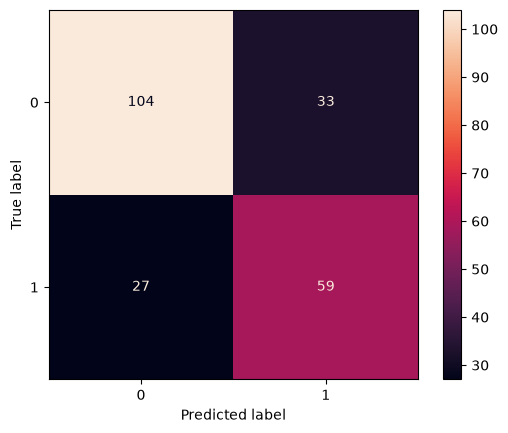

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")
plt.savefig(f"images/Cunfusion_matrix/confusion-matrix.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [45]:
joblib.dump(grid_RF.best_estimator_,"models/RandomForest_Model.joblib")
joblib.dump(grid_XG.best_estimator_,"models/XGBoost_Model.joblib")
joblib.dump(grid_lgbm.best_estimator_,"models/LightGBM_Model.joblib")
joblib.dump(grid_cat.best_estimator_,"models/CatBoost_Model.joblib")
print("Models Saved")

Models Saved
